# V44 (Rupiah Logging): LQ45 AI Strategy

**Objective**: Simulation with **Rupiah Value Logging**.

### Modification:
1. **Initial Capital**: Set to **IDR 1,000,000,000 (1 Milyar)**.
2. **Excel Output**: The `v20_portfolio_rupiah_2025.xlsx` file will show the exact **Rupiah Amount** invested in each stock (not just percentage weight).
3. **Cash Management**: Strict 10% Minimum Cash rule applies.

### Comparisons:
1. **AI Hybrid V44 (CashManaged)**.
2. **Markowitz Static (Baseline)**.
3. **IHSG Proxy (Benchmark)**.


In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_price = (1 + market_return).cumprod() * 100

print(f"Data Loaded: {len(data)} rows")


Data Loaded: 712 rows


In [2]:
# --- 2. Feature Engineering & Cost-Aware Model ---

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
ma5 = market_price.rolling(window=5).mean()
ma20 = market_price.rolling(window=20).mean()
ma50 = market_price.rolling(window=50).mean()
features['Dist_MA20'] = market_price / ma20
features['Dist_MA50'] = market_price / ma50

# Trend Signal (Standard MA50) for Hybrid Filter
trend_bullish = (market_price > ma50).astype(int)

# COST TARGET DEFINITION
next_ret = market_return.shift(-1)
COST_THRESHOLD = -0.005 
target = (next_ret > COST_THRESHOLD).astype(int)

features = features.dropna()
target = target.reindex(features.index).fillna(1) # Default to Invested
trend_bullish = trend_bullish.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

# Train Cost-Sensitive Model
xgb_model = xgb.XGBClassifier(n_estimators=120, learning_rate=0.04, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predictions
ai_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)
test_trend = trend_bullish.loc[X_test.index]

opt_t = 0.50 # Standard threshold

print(f"[Strategy] Cost-Sensitive AI Trained. Target: Stay Invested if Return > {COST_THRESHOLD*100}%")


[Strategy] Cost-Sensitive AI Trained. Target: Stay Invested if Return > -0.5%


In [3]:
# --- 3. Simulation Logic (Rupiah Logging) ---

INITIAL_CAPITAL = 1_000_000_000 # 1 Milyar IDR

def optimize_markowitz(selected_returns, min_cash=0.1):
    if len(selected_returns.columns) == 0: return {'CASH': 1.0}
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    sigma += np.eye(len(sigma)) * 1e-4 
    try:
        res = minimize(lambda w: -(np.sum(w*mu)/(np.sqrt(np.dot(w.T, np.dot(sigma, w))) + 1e-6)), 
                       [1./len(mu)]*len(mu), method='SLSQP', 
                       bounds=tuple((0, 1) for _ in range(len(mu))), 
                       constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
        
        if res.success:
            raw_weights = dict(zip(selected_returns.columns, res.x))
            final_weights = {k: v * (1.0 - min_cash) for k, v in raw_weights.items()}
            final_weights['CASH'] = min_cash
            return final_weights
        else:
            return {'CASH': 1.0}
    except:
        return {'CASH': 1.0}

def run_simulation_rupiah(strategy_type, test_dates, returns, ai_probs=None, trend_signal=None, threshold=0.5, fee=0.0025):
    # Working with Base 100 for Charting Consistency, but Log Real Value
    val = 100.0
    history = [100.0]
    dates = [test_dates[0]]
    
    prev_weights = {'CASH': 1.0}
    static_weights = None
    state_history = []
    
    # Logging list
    portfolio_log = []
    
    for i, date in enumerate(test_dates[:-1]):
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-30:loc_idx]
        
        weights = {}
        current_state = "Invested"

        if strategy_type == 'AI Hybrid V44 (Rupiah)':
            prob = ai_probs.loc[date]
            is_trend_up = trend_signal.loc[date] == 1
            is_risk_off = (prob < threshold) and (not is_trend_up)
            
            if is_risk_off:
                weights = {'CASH': 1.0}
                current_state = "Cash"
            else:
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                weights = optimize_markowitz(window_rets[valid_assets], min_cash=0.10)
                current_state = "Invested"
                
        elif strategy_type == 'Markowitz Static':
            if static_weights is None:
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                static_weights = optimize_markowitz(window_rets[valid_assets], min_cash=0.10)
            weights = static_weights
            current_state = "Static"
        
        state_history.append(current_state)
        
        # --- LOGGING IN RUPIAH ---
        # Current Portfolio Real Value
        real_value = (val / 100.0) * INITIAL_CAPITAL
        
        for asset, weight in weights.items():
            if weight > 0.001: 
                portfolio_log.append({
                    'Date': dates[-1].strftime('%Y-%m-%d'),
                    'Strategy': strategy_type,
                    'Ticker': asset,
                    'Rupiah_Value': real_value * weight # Convert Weight to IDR
                })
        
        # --- COST ---
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        # Fee on equity turnover only (Cash movement free approx)
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets if a != 'CASH')
        cost = val * turnover * fee
        val -= cost
        
        next_date = test_dates[i+1]
        
        # Returns
        day_ret = 0.0
        for asset, weight in weights.items():
            if asset != 'CASH':
                r = returns.loc[next_date, asset]
                day_ret += weight * r
        
        val *= (1 + day_ret)
        history.append(val); dates.append(next_date); prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history, 'State': state_history + [state_history[-1]]}, index=dates), portfolio_log


In [4]:
# --- 4. Models & Benchmark Execution ---

print("Running AI Hybrid V44 (Rupiah)...")
hybrid_res, hybrid_log = run_simulation_rupiah('AI Hybrid V44 (Rupiah)', X_test.index, returns, ai_probs, test_trend, threshold=0.50)

print("Running Markowitz Static...")
static_res, static_log = run_simulation_rupiah('Markowitz Static', X_test.index, returns)

print("Calculating IHSG Benchmark...")
ihsg_ret = market_return.loc[X_test.index]
ihsg_price = (1 + ihsg_ret).cumprod() * 100


Running AI Hybrid V44 (Rupiah)...
Running Markowitz Static...
Calculating IHSG Benchmark...


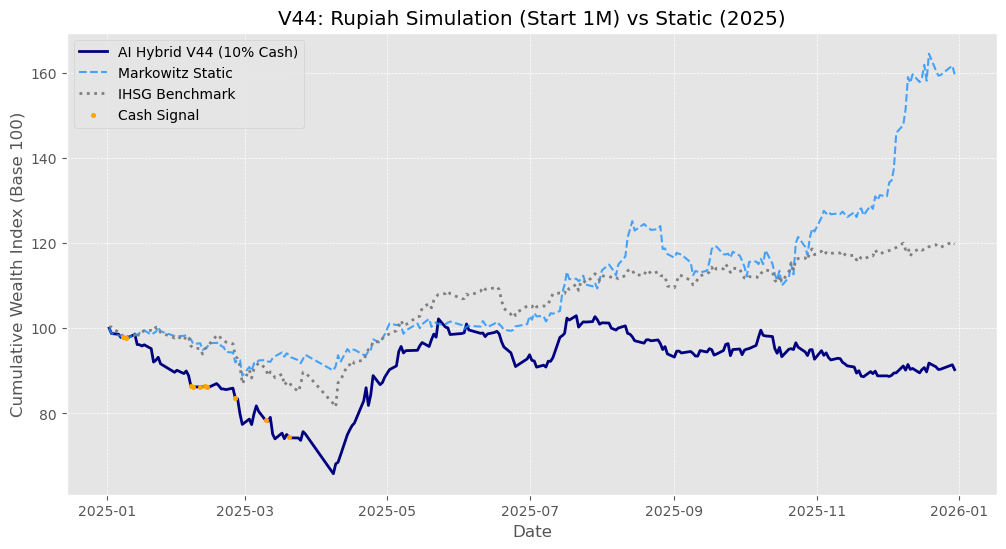

In [5]:
# --- Visualization: Performance Comparison ---
plt.figure(figsize=(12, 6))
plt.plot(hybrid_res['Portfolio_Value'], label=f'AI Hybrid V44 (10% Cash)', color='navy', linewidth=2)
plt.plot(static_res['Portfolio_Value'], label='Markowitz Static', color='dodgerblue', linestyle='--', alpha=0.8)
plt.plot(ihsg_price, label='IHSG Benchmark', color='#7f7f7f', linestyle=':', linewidth=2)

# Highlight Cash Days
regime_switches = hybrid_res[hybrid_res['State'].str.contains('Cash')]
if not regime_switches.empty:
    plt.scatter(regime_switches.index, regime_switches['Portfolio_Value'], color='orange', s=10, label='Cash Signal', zorder=5)

plt.title(f'V44: Rupiah Simulation (Start 1M) vs Static (2025)')
plt.ylabel('Cumulative Wealth Index (Base 100)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig('v44_rupiah_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [6]:
# --- 5. Export Portfolio to Excel (Rupiah Values) ---
full_log = hybrid_log + static_log
log_df = pd.DataFrame(full_log)

output_excel = 'v20_portfolio_rupiah_2025.xlsx'

with pd.ExcelWriter(output_excel) as writer:
    # Sheet 1: Hybrid Strategy Log
    hybrid_df = log_df[log_df['Strategy'] == 'AI Hybrid V44 (Rupiah)']
    if not hybrid_df.empty:
        # Pivot Values
        hybrid_pivot = hybrid_df.pivot(index='Date', columns='Ticker', values='Rupiah_Value').fillna(0)
        # Format as number
        hybrid_pivot.to_excel(writer, sheet_name='AI Hybrid Portfolio (IDR)')
    
    # Sheet 2: Static Strategy Log
    static_df = log_df[log_df['Strategy'] == 'Markowitz Static']
    if not static_df.empty:
        static_pivot = static_df.pivot(index='Date', columns='Ticker', values='Rupiah_Value').fillna(0)
        static_pivot.to_excel(writer, sheet_name='Markowitz Static (IDR)')

    # Sheet 3: Raw Log
    log_df.to_excel(writer, sheet_name='Raw Log', index=False)

print(f"Portfolio log exported to: {output_excel}")


Portfolio log exported to: v20_portfolio_rupiah_2025.xlsx
